# Phase 2 — Feature Engineering

**Steps 2.1 – 2.6** from the CartIQ proposal.

| Step | Feature Group | Features |
|---|---|---|
| 2.1 | User-Level | total_orders, avg_basket_size, avg_days_between_orders, user_reorder_rate |
| 2.2 | Product-Level | product_order_freq, product_reorder_rate, avg_add_to_cart_position |
| 2.3 | User-Product | up_times_ordered, up_reorder_ratio, up_days_since_last, up_order_streak |
| 2.4 | Temporal | order_dow, order_hour_of_day, days_since_last_order, purchase_velocity |
| 2.5 | Sequence | last 50 purchased product IDs per user (GRU input) |
| 2.6 | Save | Merge all features into final feature matrix, save to Parquet |

**Prerequisite:** Run `01_data_preparation.ipynb` first.

In [2]:
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

FEATURES_DIR = '../features'
OUTPUTS_DIR  = '../outputs'

sns.set_style('darkgrid')
print('Libraries loaded.')

Libraries loaded.


In [3]:
print('Loading prior_merged and labels from Phase 1...')
prior    = pd.read_parquet(f'{FEATURES_DIR}/prior_merged.parquet')
label_df = pd.read_parquet(f'{FEATURES_DIR}/labels.parquet')

# Sort once for all subsequent groupby operations
prior = prior.sort_values(['user_id', 'order_number', 'add_to_cart_order'])
print(f'prior shape:    {prior.shape}')
print(f'label_df shape: {label_df.shape}')

Loading prior_merged and labels from Phase 1...
prior shape:    (32434489, 15)
label_df shape: (13307953, 5)


## Step 2.1 — User-Level Features

In [4]:
# total_orders per user (max order_number in prior)
user_total_orders = (
    prior.groupby('user_id')['order_number']
         .max()
         .reset_index(name='total_orders')
)

# avg_basket_size
basket_sizes = (
    prior.groupby(['user_id', 'order_id'])
         .size()
         .reset_index(name='basket_size')
)
user_avg_basket = (
    basket_sizes.groupby('user_id')['basket_size']
                .mean()
                .reset_index(name='avg_basket_size')
)

# avg_days_between_orders
user_avg_days = (
    prior.groupby('user_id')['days_since_prior_order']
         .mean()
         .reset_index(name='avg_days_between_orders')
)

# user_reorder_rate (overall fraction of items that are reorders)
user_reorder_rate = (
    prior.groupby('user_id')['reordered']
         .mean()
         .reset_index(name='user_reorder_rate')
)

user_features = user_total_orders
user_features = user_features.merge(user_avg_basket,    on='user_id')
user_features = user_features.merge(user_avg_days,      on='user_id')
user_features = user_features.merge(user_reorder_rate,  on='user_id')

print(f'User features: {user_features.shape}')
user_features.describe()

User features: (206209, 5)


,user_id,total_orders,avg_basket_size,avg_days_between_orders,user_reorder_rate
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,15.590367,9.951586,13.013674,0.432249
std,59527.555167,16.654774,5.863570,5.661368,0.212144
min,1.000000,3.000000,1.000000,0.000000,0.000000
25%,51553.000000,5.000000,5.740741,8.475728,0.267857
50%,103105.000000,9.000000,8.933333,12.672131,0.428571
75%,154657.000000,19.000000,13.000000,17.186667,0.595745
max,206209.000000,99.000000,70.250000,29.702970,0.989529


## Step 2.2 — Product-Level Features

In [5]:
product_order_freq = (
    prior.groupby('product_id')['order_id']
         .nunique()
         .reset_index(name='product_order_freq')
)
product_reorder_rate = (
    prior.groupby('product_id')['reordered']
         .mean()
         .reset_index(name='product_reorder_rate')
)
product_avg_cart = (
    prior.groupby('product_id')['add_to_cart_order']
         .mean()
         .reset_index(name='avg_add_to_cart_position')
)

product_features = product_order_freq
product_features = product_features.merge(product_reorder_rate, on='product_id')
product_features = product_features.merge(product_avg_cart,     on='product_id')

print(f'Product features: {product_features.shape}')
product_features.describe()

Product features: (49677, 4)


,product_id,product_order_freq,product_reorder_rate,avg_add_to_cart_position
count,49677.000000,49677.000000,49677.000000,49677.000000
mean,24843.417356,652.907563,0.366461,9.097568
std,14343.034804,4792.114416,0.208103,2.551267
min,1.000000,1.000000,0.000000,1.000000
25%,12423.000000,17.000000,0.208075,7.625850
50%,24842.000000,60.000000,0.376623,9.057269
75%,37264.000000,260.000000,0.529307,10.356401
max,49688.000000,472565.000000,0.941176,53.000000


## Step 2.3 — User-Product Features

In [6]:
# up_times_ordered
up_times_ordered = (
    prior.groupby(['user_id', 'product_id'])['order_id']
         .nunique()
         .reset_index(name='up_times_ordered')
)

# up_times_reordered (reordered flag sum)
up_times_reordered = (
    prior.groupby(['user_id', 'product_id'])['reordered']
         .sum()
         .reset_index(name='up_times_reordered')
)

up_features = up_times_ordered.merge(up_times_reordered, on=['user_id', 'product_id'])
up_features['up_reorder_ratio'] = (
    up_features['up_times_reordered'] / up_features['up_times_ordered']
)

# up_days_since_last: days_since_prior_order of the most recent order containing this product
most_recent = (
    prior.sort_values(['user_id', 'product_id', 'order_number'])
         .groupby(['user_id', 'product_id'])
         .last()
         .reset_index()[['user_id', 'product_id', 'days_since_prior_order']]
)
most_recent = most_recent.rename(columns={'days_since_prior_order': 'up_days_since_last'})
up_features = up_features.merge(most_recent, on=['user_id', 'product_id'])

print(f'User-product features (before streak): {up_features.shape}')

User-product features (before streak): (13307953, 6)


In [7]:
# up_order_streak: number of consecutive orders from the most recent that contain this product
user_max_order = (
    prior.groupby('user_id')['order_number']
         .max()
         .reset_index(name='max_order_num')
)

prior_streak = prior.merge(user_max_order, on='user_id')
prior_streak['orders_from_end'] = prior_streak['max_order_num'] - prior_streak['order_number']

def compute_streak(group):
    vals = sorted(group['orders_from_end'].values)
    streak = 0
    for i, v in enumerate(vals):
        if v == i:
            streak += 1
        else:
            break
    return streak

print('Computing order streaks (may take 2-5 minutes on full dataset)...')
up_streak = (
    prior_streak.groupby(['user_id', 'product_id'])
                .apply(compute_streak)
                .reset_index(name='up_order_streak')
)
up_features = up_features.merge(up_streak, on=['user_id', 'product_id'])
print(f'User-product features (with streak): {up_features.shape}')
up_features.describe()

Computing order streaks (may take 2-5 minutes on full dataset)...


C:\Users\Yunus Kounkourou\AppData\Local\Temp\ipykernel_15952\4104360227.py:24: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_streak)


User-product features (with streak): (13307953, 7)


,user_id,product_id,up_times_ordered,up_times_reordered,up_reorder_ratio,up_days_since_last,up_order_streak
count,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07,1.330795e+07
mean,1.029987e+05,2.551351e+04,2.437226e+00,1.437226e+00,2.655049e-01,1.190756e+01,2.700782e-01
std,5.943677e+04,1.422429e+04,3.554528e+00,3.554528e+00,3.397437e-01,9.797568e+00,9.786898e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.157900e+04,1.329200e+04,1.000000e+00,0.000000e+00,0.000000e+00,5.000000e+00,0.000000e+00
50%,1.027130e+05,2.564000e+04,1.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00,0.000000e+00
75%,1.544500e+05,3.815700e+04,2.000000e+00,1.000000e+00,5.000000e-01,1.800000e+01,0.000000e+00
max,2.062090e+05,4.968800e+04,9.900000e+01,9.800000e+01,9.898990e-01,3.000000e+01,9.900000e+01


## Step 2.4 — Temporal Features

In [8]:
# Use each user's most recent prior order for temporal signals
latest_order = (
    prior.sort_values(['user_id', 'order_number'])
         .groupby('user_id')
         .last()
         .reset_index()
)
temporal_features = latest_order[['user_id', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']].copy()
temporal_features = temporal_features.rename(
    columns={'days_since_prior_order': 'days_since_last_order'}
)

# purchase_velocity: total items ordered / total active days
user_span = (
    prior.groupby('user_id')
         .agg(total_items=('product_id', 'count'),
              total_days=('days_since_prior_order', 'sum'))
         .reset_index()
)
user_span['purchase_velocity'] = user_span['total_items'] / (user_span['total_days'] + 1)

temporal_features = temporal_features.merge(
    user_span[['user_id', 'purchase_velocity']], on='user_id'
)

print(f'Temporal features: {temporal_features.shape}')
temporal_features.describe()

Temporal features: (206209, 5)


,user_id,order_dow,order_hour_of_day,days_since_last_order,purchase_velocity
count,206209.000000,206209.000000,206209.000000,206209.000000,206209.000000
mean,103105.000000,2.749846,13.557948,16.081413,0.102716
std,59527.555167,2.064458,4.208875,10.434509,0.218289
min,1.000000,0.000000,0.000000,0.000000,0.033655
25%,51553.000000,1.000000,10.000000,7.000000,0.058091
50%,103105.000000,3.000000,14.000000,14.000000,0.078788
75%,154657.000000,5.000000,17.000000,30.000000,0.117745
max,206209.000000,6.000000,23.000000,30.000000,39.000000


## Step 2.5 — GRU Sequences (Last 50 Products per User)

In [9]:
MAX_SEQ_LEN = 50

user_sequences = (
    prior.sort_values(['user_id', 'order_number', 'add_to_cart_order'])
         .groupby('user_id')['product_id']
         .apply(list)
         .reset_index()
)
user_sequences.columns = ['user_id', 'product_sequence']

# Truncate to last MAX_SEQ_LEN items
user_sequences['product_sequence'] = user_sequences['product_sequence'].apply(
    lambda seq: seq[-MAX_SEQ_LEN:]
)

print(f'GRU sequences built for {len(user_sequences):,} users')
print(f'Avg sequence length:  {user_sequences["product_sequence"].apply(len).mean():.1f}')
print(f'Max sequence length:  {user_sequences["product_sequence"].apply(len).max()}')

with open(f'{FEATURES_DIR}/user_sequences.pkl', 'wb') as f:
    pickle.dump(user_sequences, f)
print('Saved user_sequences.pkl')

GRU sequences built for 206,209 users
Avg sequence length:  42.8
Max sequence length:  50
Saved user_sequences.pkl


## Step 2.6 — Merge All Features & Save to Parquet

In [10]:
feature_df = label_df.copy()
feature_df = feature_df.merge(user_features,     on='user_id',                how='left')
feature_df = feature_df.merge(product_features,  on='product_id',             how='left')
feature_df = feature_df.merge(up_features,        on=['user_id', 'product_id'], how='left')
feature_df = feature_df.merge(temporal_features,  on='user_id',                how='left')

print(f'Final feature matrix shape: {feature_df.shape}')

# Check for any remaining nulls
null_counts = feature_df.isnull().sum()
print(f'Columns with nulls:\n{null_counts[null_counts > 0]}')

feature_df = feature_df.fillna(0)
print('\nFilled remaining NaN with 0.')

Final feature matrix shape: (13307953, 21)
Columns with nulls:
Series([], dtype: int64)

Filled remaining NaN with 0.


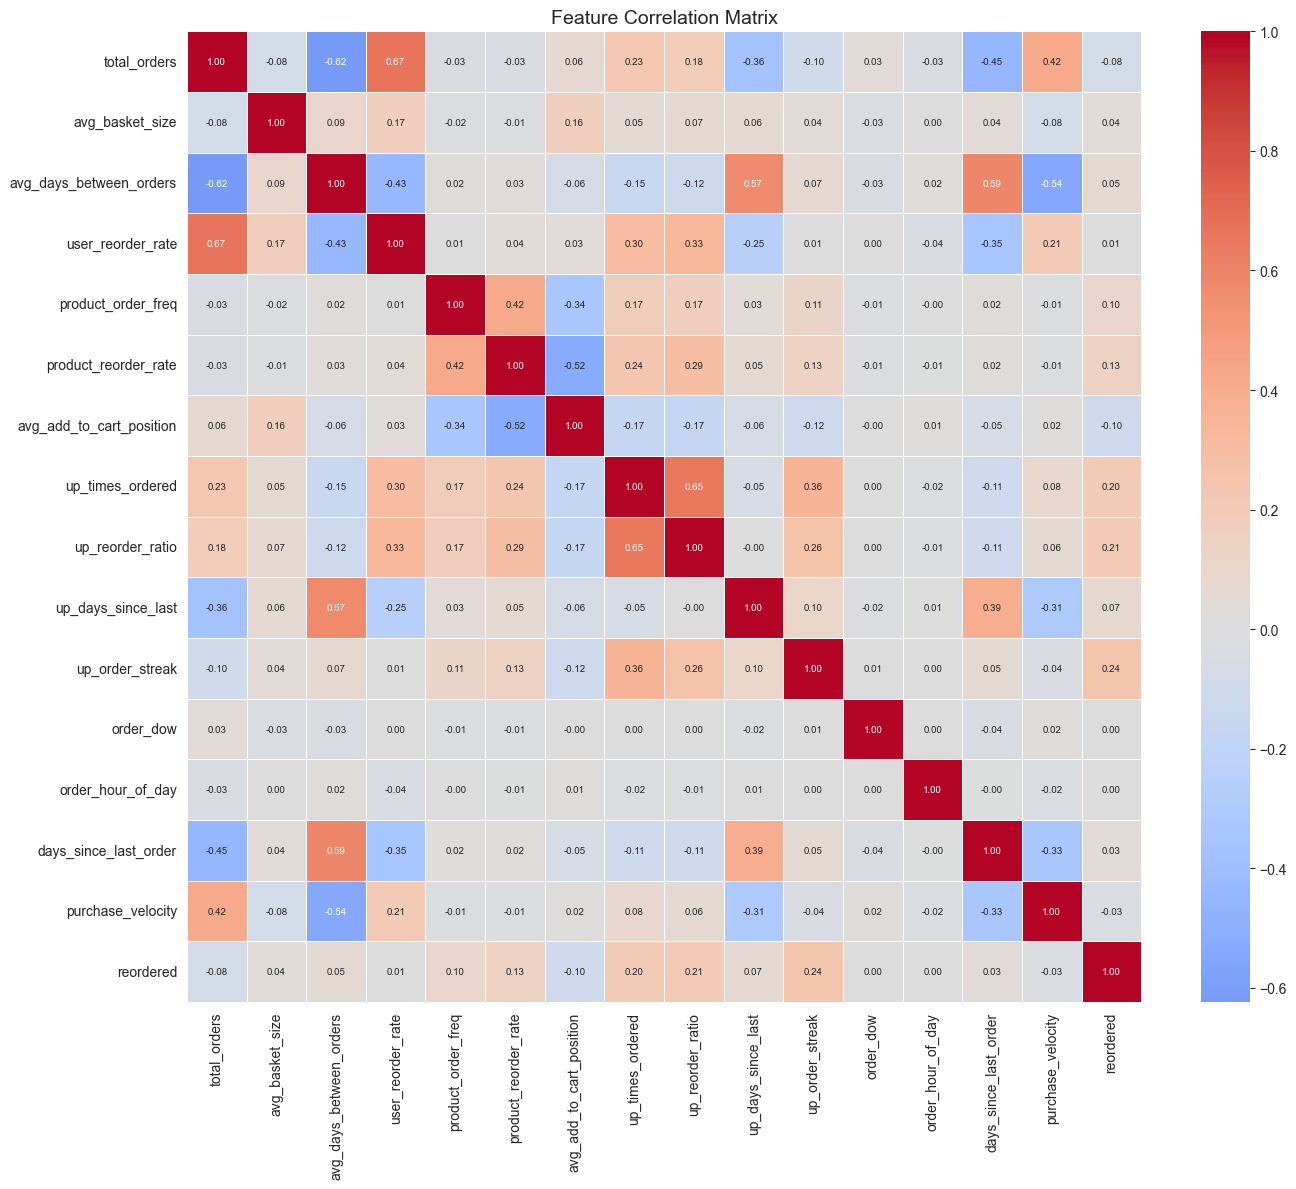

In [11]:
# Feature correlation heatmap
FEATURE_COLS = [
    'total_orders', 'avg_basket_size', 'avg_days_between_orders', 'user_reorder_rate',
    'product_order_freq', 'product_reorder_rate', 'avg_add_to_cart_position',
    'up_times_ordered', 'up_reorder_ratio', 'up_days_since_last', 'up_order_streak',
    'order_dow', 'order_hour_of_day', 'days_since_last_order', 'purchase_velocity',
]

sample = feature_df[FEATURE_COLS + ['reordered']].sample(50000, random_state=42)
corr = sample.corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig(f'{OUTPUTS_DIR}/02_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
print('Saving feature files to Parquet...')
feature_df.to_parquet(f'{FEATURES_DIR}/feature_matrix.parquet', index=False)
user_features.to_parquet(f'{FEATURES_DIR}/user_features.parquet', index=False)
product_features.to_parquet(f'{FEATURES_DIR}/product_features.parquet', index=False)
up_features.to_parquet(f'{FEATURES_DIR}/up_features.parquet', index=False)

print(f'  feature_matrix.parquet   — {len(feature_df):,} rows, {len(feature_df.columns)} cols')
print(f'  user_features.parquet    — {len(user_features):,} rows')
print(f'  product_features.parquet — {len(product_features):,} rows')
print(f'  up_features.parquet      — {len(up_features):,} rows')
print('Phase 2 complete. Proceed to 03_baseline_gbdt.ipynb')

Saving feature files to Parquet...
  feature_matrix.parquet   — 13,307,953 rows, 21 cols
  user_features.parquet    — 206,209 rows
  product_features.parquet — 49,677 rows
  up_features.parquet      — 13,307,953 rows
Phase 2 complete. Proceed to 03_baseline_gbdt.ipynb
